In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, RepeatVector, Rescaling, Resizing
from tensorflow.keras.layers import LSTM,Bidirectional,GRU
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.utils import to_categorical
#from tensorflow.keras.backend import function

import datetime
import io
import itertools
# import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import sys
import os
# Obtener la ruta del directorio actual
os.chdir('..')
current_dir = os.getcwd()
print(current_dir)

# Construir la ruta relativa al directorio que quieres agregar
relative_dir = os.path.join(current_dir, 'mis_pkgs/')

# Agregar la ruta relativa al sys.path
sys.path.insert(0, relative_dir)

#from MIOPATIA_db import DB_management as db 


2024-08-19 20:21:45.244009: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-19 20:21:45.244058: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-19 20:21:45.244960: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-19 20:21:45.251019: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-19 20:21:46.187311: W tensorflow/compiler/tf2

/home/rgadea/nuevas_investigaciones_alimentos_2024


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


2024-08-19 20:21:47.932930: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-08-19 20:21:47.959609: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-08-19 20:21:47.959699: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
numero_muestras=150
numero_clases=2
entrada=[4]
numero_entradas = 1
numero_epochs=20000

Voy a quedarme con los 50 atunes P1 para obtener conjunto de training y validacion

In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Add, Activation, Concatenate, Conv2D, Dropout 
from tensorflow.keras.layers import Flatten, Input, GlobalAveragePooling2D, MaxPooling2D
import tensorflow.keras.backend as K

__version__ = '0.0.1'


def SqueezeNet(input_shape, nb_classes, use_bypass=False, dropout_rate=None, compression=1.0):
    """
    Creating a SqueezeNet of version 1.0
    
    Arguments:
        input_shape  : shape of the input images e.g. (224,224,3)
        nb_classes   : number of classes
        use_bypass   : if true, bypass connections will be created at fire module 3, 5, 7, and 9 (default: False)
        dropout_rate : defines the dropout rate that is accomplished after last fire module (default: None)
        compression  : reduce the number of feature-maps (default: 1.0)
        
    Returns:
        Model        : Keras model instance
    """
    
    input_img = Input(shape=input_shape)

    x = Conv2D(int(96*compression), (7,7), activation='relu', strides=(2,2), padding='same', name='conv1')(input_img)

    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool1')(x)
    
    x = create_fire_module(x, int(16*compression), name='fire2')
    x = create_fire_module(x, int(16*compression), name='fire3', use_bypass=use_bypass)
    x = create_fire_module(x, int(32*compression), name='fire4')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool4')(x)
    
    x = create_fire_module(x, int(32*compression), name='fire5', use_bypass=use_bypass)
    x = create_fire_module(x, int(48*compression), name='fire6')
    x = create_fire_module(x, int(48*compression), name='fire7', use_bypass=use_bypass)
    x = create_fire_module(x, int(64*compression), name='fire8')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool8')(x)
    
    x = create_fire_module(x, int(64*compression), name='fire9', use_bypass=use_bypass)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)
        
    x = output(x, nb_classes)

    return Model(inputs=input_img, outputs=x)


def SqueezeNet_11(input_shape, nb_classes, dropout_rate=None, compression=1.0):
    """
    Creating a SqueezeNet of version 1.1
    
    2.4x less computation over SqueezeNet 1.0 implemented above.
    
    Arguments:
        input_shape  : shape of the input images e.g. (224,224,3)
        nb_classes   : number of classes
        dropout_rate : defines the dropout rate that is accomplished after last fire module (default: None)
        compression  : reduce the number of feature-maps
        
    Returns:
        Model        : Keras model instance
    """
    
    input_img = Input(shape=input_shape)

    x = Conv2D(int(64*compression), (3,3), activation='relu', strides=(2,2), padding='same', name='conv1')(input_img)

    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool1')(x)
    
    x = create_fire_module(x, int(16*compression), name='fire2')
    x = create_fire_module(x, int(16*compression), name='fire3')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool3')(x)
    
    x = create_fire_module(x, int(32*compression), name='fire4')
    x = create_fire_module(x, int(32*compression), name='fire5')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool5')(x)
    
    x = create_fire_module(x, int(48*compression), name='fire6')
    x = create_fire_module(x, int(48*compression), name='fire7')
    x = create_fire_module(x, int(64*compression), name='fire8')
    x = create_fire_module(x, int(64*compression), name='fire9')

    if dropout_rate:
        x = Dropout(dropout_rate)(x)
    
    # Creating last conv10
    x = output(x, nb_classes)

    return Model(inputs=input_img, outputs=x)


def output(x, nb_classes):
    x = Conv2D(nb_classes, (1,1), strides=(1,1), padding='valid', name='conv10')(x)
    x = GlobalAveragePooling2D(name='avgpool10')(x)
    x = Activation("softmax", name='softmax')(x)
    return x


def create_fire_module(x, nb_squeeze_filter, name, use_bypass=False):
    """
    Creates a fire module
    
    Arguments:
        x                 : input
        nb_squeeze_filter : number of filters of squeeze. The filtersize of expand is 4 times of squeeze
        use_bypass        : if True then a bypass will be added
        name              : name of module e.g. fire123
    
    Returns:
        x                 : returns a fire module
    """
    
    nb_expand_filter = 4 * nb_squeeze_filter
    squeeze    = Conv2D(nb_squeeze_filter,(1,1), activation='relu', padding='same', name='%s_squeeze'%name)(x)
    expand_1x1 = Conv2D(nb_expand_filter, (1,1), activation='relu', padding='same', name='%s_expand_1x1'%name)(squeeze)
    expand_3x3 = Conv2D(nb_expand_filter, (3,3), activation='relu', padding='same', name='%s_expand_3x3'%name)(squeeze)
    
    axis = get_axis()
    x_ret = Concatenate(axis=axis, name='%s_concatenate'%name)([expand_1x1, expand_3x3])
    
    if use_bypass:
        x_ret = Add(name='%s_concatenate_bypass'%name)([x_ret, x])
        
    return x_ret


def get_axis():
    axis = -1 if K.image_data_format() == 'channels_last' else 1
    return axis


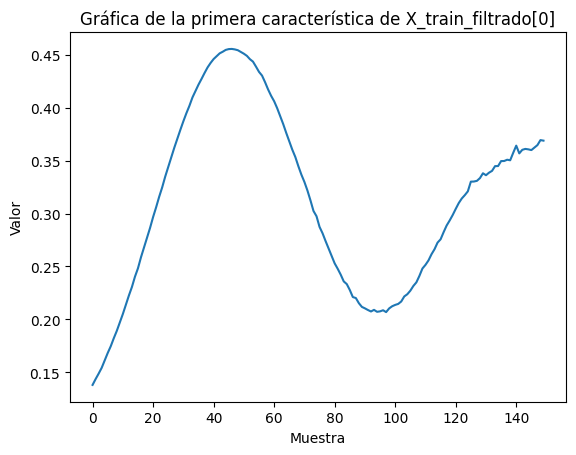

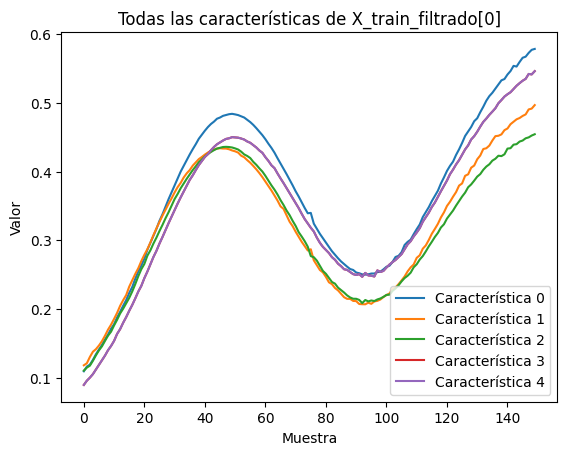

In [5]:
filename = "COPIA_PANDAS/medidas_agilent_2023_y_2024_201_puntos_clasificados.hdf"
with pd.HDFStore(filename,complib="zlib",complevel=4) as hdf_db:
    pre_p_e1  = hdf_db.get('data/pollos_estado')
    pre_p_e1 = pre_p_e1.loc[pre_p_e1['Pollo'] != 0]
    # p_e =pre_p_e1.drop_duplicates(subset = ['Pollo', 'Medida'],  keep = 'last').reset_index(drop = True)
    t    = hdf_db.get('data/tabla')
    X_train=[]

    y_train=[]
    x=0
    for index, row in pre_p_e1.iterrows():   # El primer registro no se toma en cuenta porque es basura
        Primero = int(row['Primero'])
        Ultimo  = int(row['Ultimo'])
        estado  = int(row['Estado'])
        #print(Primero)
        #print(Ultimo)
        #print(estado)
        if (estado<5):
            if numero_clases==2:
                if estado == 0 or estado== 1:
                    target = 0
                else:
                    target = 1
            else:
                target=estado
            pepito=np.array(t.iloc[Primero+50:Primero+200])
        # #print(pepito.shape)
            X_train.append(pepito[:,entrada])
        #X_train[x,:, 0] = pepito[:, 2] * pepito[:, 5]
        #X_train[x,:, 1] = pepito[:, 2] * pepito[:, 6]

        #print(X_train[x][0:4,:])       
            y_train.append(target)
            y_train_to_categorical = to_categorical(y_train)
            x=x+1

X_train_filtrado=np.zeros((x,numero_muestras,numero_entradas))
X_train = np.array(X_train)
y_train = np.array(y_train)
#X_train_filtrado[:,:,0] =(np.log(X_train[:,:,0])/16) 
X_train_filtrado[:,:,0]=-X_train[:,:,0]*2*180/(np.pi*256)

#y_train_filtrado = y_train
y_train_filtrado = y_train_to_categorical


scaler = MinMaxScaler(feature_range=(0, 1))
#scaler = StandardScaler()



#data1=np.concatenate((X_train_filtrado,X_test_filtrado1),axis=0) 

data_2d = X_train_filtrado.reshape(-1, X_train_filtrado.shape[-1])
normalized_data_2d = scaler.fit_transform(data_2d)



X_train_Normalizado=normalized_data_2d.reshape(X_train_filtrado.shape)
y_train_Normalizado=y_train_filtrado

# print(X_train_filtrado[1])
plt.plot(X_train_filtrado[7][:, 0])
plt.title('Gráfica de la primera característica de X_train_filtrado[0]')
plt.xlabel('Muestra')
plt.ylabel('Valor')
plt.show()

# Si quieres plotear todas las características de X_train_filtrado[0] en la misma gráfica:
for i in range(5):
    plt.plot(X_train_filtrado[i][:, 0], label=f'Característica {i}')
plt.title('Todas las características de X_train_filtrado[0]')
plt.xlabel('Muestra')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [ ]:
new_model=tf.keras.models.load_model('modelos/modelo_perfecto_para_matlab_redpitaya_julio_2024')

In [6]:
# filename = "COPIA_PANDAS\hdf_lomosAgilent_test_filtrado_def_good.hdf"
# with pd.HDFStore(filename,complib="zlib",complevel=4) as hdf_db:
#     pre_p_e1  = hdf_db.get('data/pollos_estado')
#     pre_p_e1 = pre_p_e1.loc[pre_p_e1['Pollo'] != 0]
#     pre_p_e1 =pre_p_e1.drop_duplicates(subset = ['Pollo', 'Medida'],  keep = 'last').reset_index(drop = True)
#     t    = hdf_db.get('data/tabla')
#     X_test=np.zeros((pre_p_e1.shape[0],numero_muestras,numero_entradas))
#     y_test=np.zeros((pre_p_e1.shape[0],1))
#     y_test2=np.zeros((pre_p_e1.shape[0],1))    
#     x=0
#     for index, row in pre_p_e1.iterrows():   # El primer registro no se toma en cuenta porque es basura
#         Primero = int(row['Primero'])
#         Ultimo  = int(row['Ultimo'])
#         estado  = int(row['Estado'])
#         #print(Primero)
#         #print(Ultimo)
#         #print(estado)
#         if numero_clases==2:
#             if estado == 0 or estado== 1:
#                 target = 0
#             else:
#                 target = 1

#         else:
#             target=estado
#         pepito=np.array(t.iloc[Primero:Ultimo+1])
#         # #print(pepito.shape)
#         X_test[x]=pepito[:,entrada]
#         #print(X_train[x][0:4,:])       
#         y_test[x]=target
#         #y_test2[x]=target2
#         y_test_to_categorical = to_categorical(y_test)
#         #y_test2_to_categorical = to_categorical(y_test2)        
#         x=x+1


# # print(X_train.shape)
# # print(y_train_to_categorical.shape)
# # #print(X_train[0:4,:,:])
# # #print(X_train[1][0:4][:])
# # print(y_train[1:20])
# # print(y_train_to_categorical[1:20])
# # # #Aqui filtrariamos si hay filas que no nos interesan. En este caso dejo pasar todos los casos
# # print(p_e)
# # # X_train_filtrado = X_train[2:][:,:]
# # # y_train_filtrado = y_train[2:]
# X_test_filtrado = X_test
# #y_train_filtrado = y_train
# y_test_filtrado = y_test_to_categorical
# #y_test2_filtrado = y_test2_to_categorical

# print(X_test_filtrado.shape)
# print(y_test_filtrado.shape)
# # print(X_train_filtrado[0][:,:])
# # # # Vamos a normalizar o escalar los datos
# # concatenamos train y test
# #X_total=np.concatenate((X_train_filtrado,X_test_filtrado),axis=0)
# #scaler = MinMaxScaler(feature_range=(0, 1))
# #data_2d_test = X_total.reshape(-1, X_total.shape[-1])
# data_2d_test = X_test_filtrado.reshape(-1, X_test_filtrado.shape[-1])
# normalized_data_2d_test = scaler.transform(data_2d_test)


# X_test_def=normalized_data_2d_test.reshape(X_test_filtrado.shape) 
# # la alternativa es normalizar con el total
# # X_test_def=normalized_data_2d_test.reshape(X_test_filtrado.shape) 

# y_test_def=y_test_filtrado # los valores ya estaban normalizados
# #y_test_def2=y_test2_filtrado # los valores ya estaban normalizados
# print(X_test_def[0])

Vamos a hacer los conjuntos de entrenamiento validacion y test

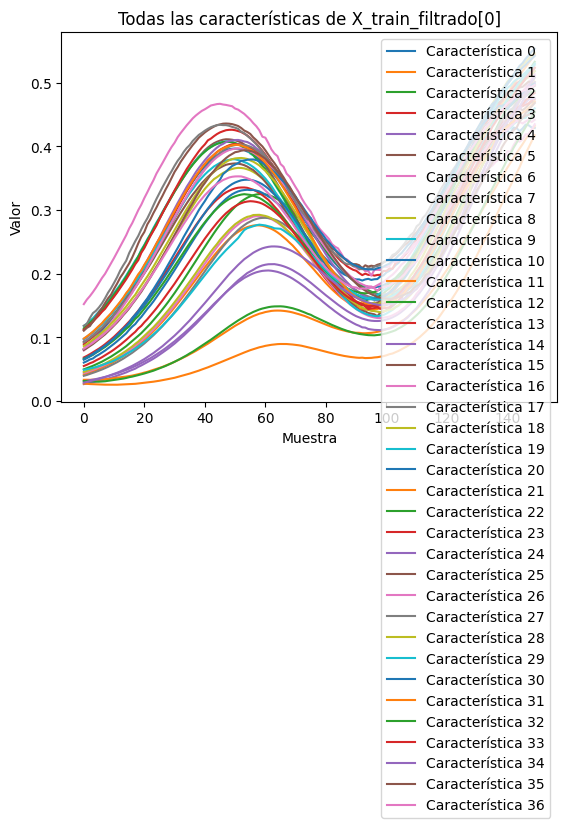

In [7]:
# Divide el dataset en entrenamiento y temporal (test+validación)
# X_temp, X_test_def, y_temp, y_test_def = train_test_split(X_train_Normalizado, y_train_Normalizado, test_size=0.2, stratify=y_train_Normalizado, random_state=42)

# Divide el dataset temporal en validación y test
X_train_def, X_val_def, y_train_def, y_val_def = train_test_split(X_train_filtrado, y_train_filtrado, test_size=0.20, stratify=y_train_Normalizado, random_state=42)

# Ahora, X_train, X_val y X_test contienen los datos de entrada para los conjuntos de entrenamiento, validación y prueba, respectivamente.
# y_train, y_val y y_test contienen las clases correspondientes.
# Si quieres plotear todas las características de X_train_filtrado[0] en la misma gráfica:
for i in range(X_val_def.shape[0]):
    plt.plot(X_val_def[i][:, 0], label=f'Característica {i}')
plt.title('Todas las características de X_train_filtrado[0]')
plt.xlabel('Muestra')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [8]:
print(X_train_def.shape)
print(X_val_def.shape)
#print(X_test_def.shape)
print(y_train_def.shape)
print(y_val_def.shape)
#print(y_test_def.shape)

(147, 150, 1)
(37, 150, 1)
(147, 2)
(37, 2)


In [9]:
#%load_ext tensorboard

#%tensorboard --logdir logs
#log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
#tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

In [10]:
def plot_to_image(figure):
    """
    Converts the matplotlib plot specified by 'figure' to a PNG image and
    returns it. The supplied figure is closed and inaccessible after this call.
    """
    
    buf = io.BytesIO()
    
    # Use plt.savefig to save the plot to a PNG in memory.
    plt.savefig(buf, format='png')
    
    # Closing the figure prevents it from being displayed directly inside
    # the notebook.
    plt.close(figure)
    buf.seek(0)
    
    # Use tf.image.decode_png to convert the PNG buffer
    # to a TF image. Make sure you use 4 channels.
    image = tf.image.decode_png(buf.getvalue(), channels=4)
    
    # Use tf.expand_dims to add the batch dimension
    image = tf.expand_dims(image, 0)
    
    return image

In [11]:
def plot_confusion_matrix(cm, class_names):
    """
    Returns a matplotlib figure containing the plotted confusion matrix.
    
    Args:
       cm (array, shape = [n, n]): a confusion matrix of integer classes
       class_names (array, shape = [n]): String names of the integer classes
    """
    
    figure = plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    
    # Normalize the confusion matrix.
    cm = np.around(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis], decimals=2)
    
    # Use white text if squares are dark; otherwise black.
    threshold = cm.max() / 2.
    threshold = 0.5
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        color = "red" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j], horizontalalignment="center", color=color)
        
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    return figure

In [12]:
factor_aprendizaje=0.001
dimension_LSTM=32
dimension_dense=50
algoritmo='rmsprop'
supermax=8*4
lossfunction='categorical_crossentropy'
def create_model():

    model = Sequential()
    #model.add(Input(shape=(401, 8)))
    model.add(GRU(dimension_LSTM, return_sequences=True, recurrent_regularizer='L1L2', input_shape=(numero_muestras,numero_entradas), activation='tanh'))
    model.add(Reshape((numero_muestras, dimension_LSTM, 1))) 
    #model.add(Resizing(numero_muestras, 4*dimension_LSTM))
    #model.add(Conv2D(3, (1, 1), padding='same'))
    model.add(Rescaling(2048, offset=256))
    model.add(SqueezeNet_11(input_shape=(numero_muestras,dimension_LSTM, 1), nb_classes=numero_clases, dropout_rate=0.5, compression=1.0))
    #model.add(SqueezeNet_11(input_shape=(401,100, 1), nb_classes=5, dropout_rate=0.5, compression=1.0))
    model.compile(loss=lossfunction, optimizer=algoritmo, metrics=['accuracy'])
    model.optimizer.lr=(factor_aprendizaje)
    return model

model=create_model()

2024-08-19 20:21:50.666759: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-08-19 20:21:50.666875: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-08-19 20:21:50.666914: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-08-19 20:21:50.799316: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-08-19 20:21:50.799433: I external/local_xla/xla/stream_executor

In [13]:
# Generar una lista de los números en el rango del slice
# numbers = list(range(entrada.start, entrada.stop))

# Convertir la lista a un string con los números separados por guiones
#slice_str = "-".join(map(str, numbers))
slice_str = "4"
experimento="LOMOS_Agilent_entradas_{}_GRU_{}_squeezenetv1_1_clases_{}_loss_{}_lr_{}_algoritmo_{}".format(slice_str,dimension_LSTM,numero_clases,lossfunction,factor_aprendizaje,algoritmo)
logdir="./logs/defs/{}_{}".format(experimento,datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback=tf.keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=1)
file_writer_cm = tf.summary.create_file_writer(logdir + '/cm')


In [14]:
class_names=["Buenos","Malos"]

In [15]:
def log_confusion_matrix(epoch, logs):
    
    # Use the model to predict the values from the test_images.
    y_pred = model.predict(X_test_def)
    #y_pred1=y_pred[:,-1]
    y_pred2=y_pred.argmax(axis=1)
    #y_pred2=np.where(y_pred>0,1,0)
    #y_pred2=y_pred2[:,-1]
    #classes = [0, 1, 2, 3, 4] 
    classes = [0, 1]
    y_test_def2=np.argmax(y_test_def,axis=1)  
    #y_test_def2=np.where(y_test_def>0,1,0)
    cm=confusion_matrix(y_test_def2, y_pred2,labels=classes)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    figura = plot_confusion_matrix(cm, class_names=class_names)
    cm_image = plot_to_image(figura)
    
    # Log the confusion matrix as an image summary.
    with file_writer_cm.as_default():
        tf.summary.image("Confusion Matrix", cm_image, step=epoch)

In [16]:
cm_callback = tf.keras.callbacks.LambdaCallback(on_epoch_end=log_confusion_matrix)
print(y_train_Normalizado.shape)
print(y_val_def.shape)

(184, 2)
(37, 2)


In [17]:
# Crear un callback para guardar los mejores pesos
#checkpoint = tf.keras.callbacks.ModelCheckpoint('best_weights.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')


In [18]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.95,
    patience=1000,
    min_lr=0.0001
)
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0, patience=2000, verbose=2, mode='auto', baseline=None, restore_best_weights=True)
model.fit(X_train_def, y_train_def, epochs=numero_epochs, batch_size=20, callbacks=[tensorboard_callback,early_stop], validation_data=(X_val_def, y_val_def))
# Final evaluation of the model 
scores = model.evaluate(X_val_def, y_val_def, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Epoch 1/20000


2024-08-19 20:21:54.678334: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/model/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2024-08-19 20:21:55.089079: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-08-19 20:21:55.243934: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-08-19 20:21:56.158123: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fddb6540070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-08-19 20:21:56.158173: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1070 Ti, Compute Capability 6.1
2024-08-19 20:21:56.163353: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR cra

8/8 [==============================] - 9s 412ms/step - loss: 0.6941 - accuracy: 0.4558 - val_loss: 0.6873 - val_accuracy: 0.5946
Epoch 2/20000
8/8 [==============================] - 1s 102ms/step - loss: 0.6872 - accuracy: 0.5782 - val_loss: 0.6823 - val_accuracy: 0.5946
Epoch 3/20000
8/8 [==============================] - 1s 96ms/step - loss: 0.6878 - accuracy: 0.5782 - val_loss: 0.6813 - val_accuracy: 0.5946
Epoch 4/20000
8/8 [==============================] - 1s 120ms/step - loss: 0.6836 - accuracy: 0.5782 - val_loss: 0.6794 - val_accuracy: 0.5946
Epoch 5/20000
8/8 [==============================] - 1s 87ms/step - loss: 0.6830 - accuracy: 0.5782 - val_loss: 0.6782 - val_accuracy: 0.5946
Epoch 6/20000
8/8 [==============================] - 1s 89ms/step - loss: 0.6830 - accuracy: 0.5782 - val_loss: 0.6761 - val_accuracy: 0.5946
Epoch 7/20000
8/8 [==============================] - 1s 86ms/step - loss: 0.6814 - accuracy: 0.5782 - val_loss: 0.6785 - val_accuracy: 0.5946
Epoch 8/20000
8/8

In [19]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 150, 32)           3360      
                                                                 
 reshape (Reshape)           (None, 150, 32, 1)        0         
                                                                 
 rescaling (Rescaling)       (None, 150, 32, 1)        0         
                                                                 
 model (Functional)          (None, 2)                 722370    
                                                                 
Total params: 725730 (2.77 MB)
Trainable params: 725730 (2.77 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2/2 [==============================] - 0s 5ms/step
(150, 32)


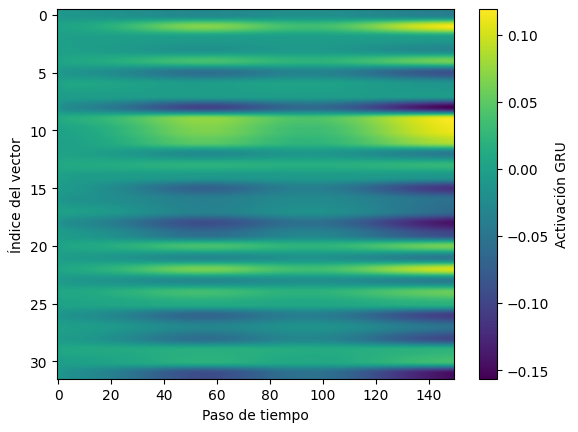

In [20]:
#salida=model.predict(X_test_def)    
inputs=model.layers[0].input
# Asume que model es tu modelo original y que quieres la salida de la primera capa
output_layer = model.layers[0].output

# Crea un nuevo modelo que tenga la misma entrada que el modelo original, pero cuya salida sea la salida de la capa que te interesa
intermediate_model = tf.keras.Model(inputs=inputs, outputs=output_layer)


X = X_val_def
gru_output = intermediate_model.predict(X)
print(gru_output[0].shape)

# Visualiza la salida de la GRU
plt.imshow(gru_output[10].T, aspect='auto', cmap='viridis')
plt.colorbar(label='Activación GRU')
plt.xlabel('Paso de tiempo')
plt.ylabel('Índice del vector')
plt.show()

2/2 [==============================] - 0s 5ms/step


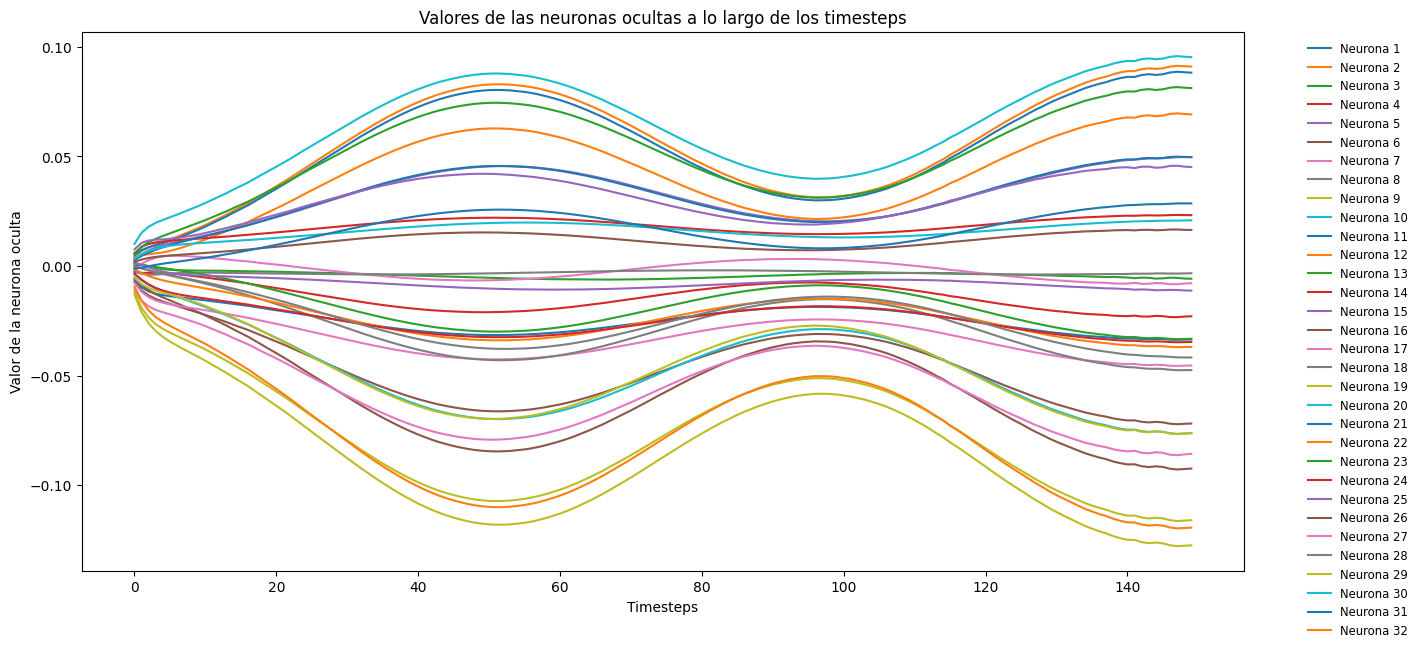

In [21]:
X = X_val_def
gru_output = intermediate_model.predict(X)
# Transponer la matriz para que los timesteps estén en el eje de las abscisas
# y los valores de las neuronas ocultas en el eje de las ordenadas
sequence = gru_output[0]

# Plotear los valores de las neuronas ocultas a lo largo de los timesteps
timesteps = sequence.shape[0]
neurons = sequence.shape[1]

plt.figure(figsize=(15, 7))
for neuron in range(neurons):
    plt.plot(range(timesteps), sequence[:, neuron], label=f'Neurona {neuron+1}')

plt.xlabel('Timesteps')
plt.ylabel('Valor de la neurona oculta')
plt.title('Valores de las neuronas ocultas a lo largo de los timesteps')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), ncol=1, fontsize='small', frameon=False)
plt.show()

2/2 [==============================] - 0s 10ms/step
(37, 150, 1)


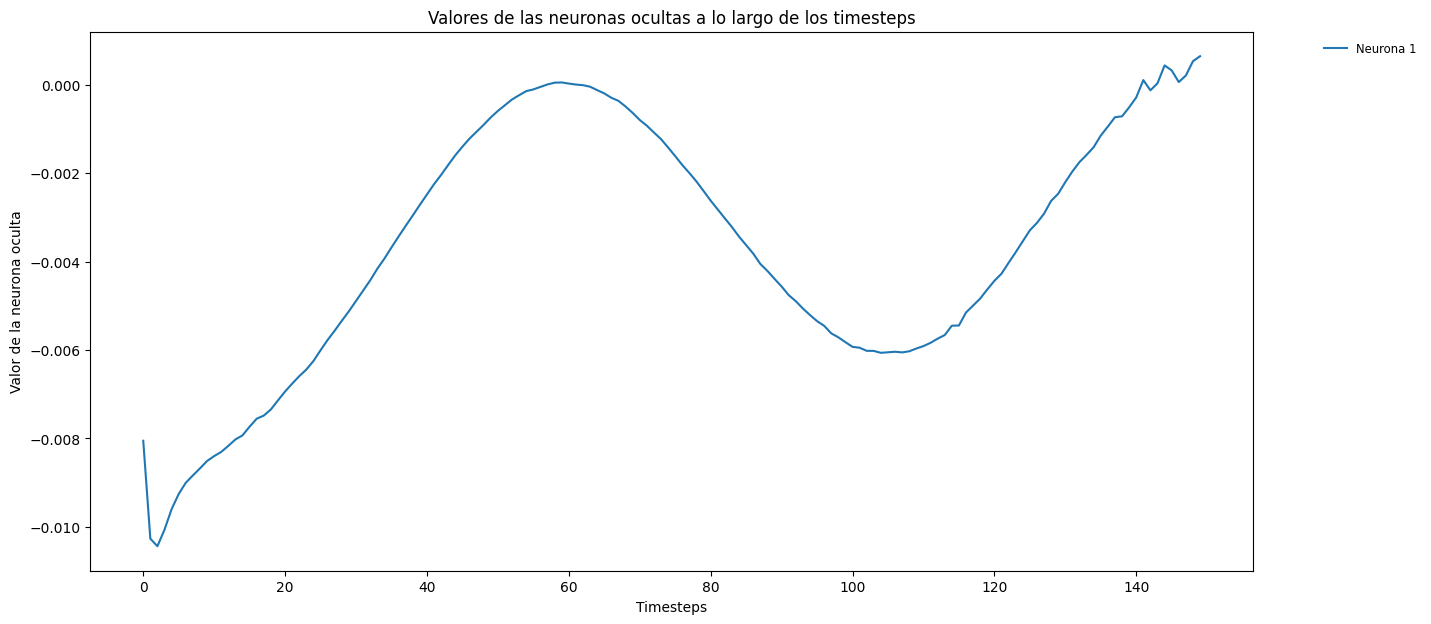

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, TimeDistributed, Dense
X = X_val_def
gru_output = intermediate_model.predict(X)
outputs = TimeDistributed(Dense(1))(gru_output)

print(outputs.shape)

# Transponer la matriz para que los timesteps estén en el eje de las abscisas
# y los valores de las neuronas ocultas en el eje de las ordenadas
sequence = outputs[0]

# Plotear los valores de las neuronas ocultas a lo largo de los timesteps
timesteps = sequence.shape[0]
neurons = sequence.shape[1]

plt.figure(figsize=(15, 7))
for neuron in range(neurons):
    plt.plot(range(timesteps), sequence[:, neuron], label=f'Neurona {neuron+1}')

plt.xlabel('Timesteps')
plt.ylabel('Valor de la neurona oculta')
plt.title('Valores de las neuronas ocultas a lo largo de los timesteps')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), ncol=1, fontsize='small', frameon=False)
plt.show()

In [23]:
y_pred = model.predict(X_val_def)
#y_pred1=y_pred[:,-1]
y_pred2=np.argmax(y_pred,axis=1)
#y_pred2=np.where(y_pred>0,1,0)
#y_pred2=y_pred2[:,-1]
y_test_def2=np.argmax(y_val_def,axis=1)
#y_test_def2=np.where(y_test_def>0,1,0)
print(y_pred.shape)
print(y_pred2.shape)
print(y_test_def2.shape)
#print(y_test_def[25])
print(y_pred)
print(y_pred2)

2/2 [==============================] - 0s 9ms/step
(37, 2)
(37,)
(37,)
[[0.51688766 0.4831123 ]
 [0.51688445 0.48311555]
 [0.5168875  0.48311254]
 [0.5168825  0.48311755]
 [0.5168809  0.48311907]
 [0.5168888  0.48311123]
 [0.5168854  0.4831146 ]
 [0.5168849  0.48311505]
 [0.5168857  0.48311433]
 [0.5168893  0.48311073]
 [0.5168818  0.4831182 ]
 [0.5168803  0.4831197 ]
 [0.5168861  0.4831139 ]
 [0.51688635 0.48311365]
 [0.51688945 0.48311052]
 [0.5168878  0.48311222]
 [0.5168777  0.4831223 ]
 [0.5168895  0.4831105 ]
 [0.51688576 0.48311427]
 [0.51688766 0.48311234]
 [0.5168841  0.4831159 ]
 [0.51687163 0.48312837]
 [0.51688206 0.48311797]
 [0.51688784 0.48311213]
 [0.5168814  0.4831186 ]
 [0.5168841  0.48311594]
 [0.51688826 0.48311174]
 [0.5168822  0.48311782]
 [0.5168904  0.48310956]
 [0.51688445 0.48311552]
 [0.51688164 0.4831183 ]
 [0.5168909  0.48310906]
 [0.5168805  0.48311946]
 [0.51688576 0.48311424]
 [0.51687974 0.48312026]
 [0.516888   0.483112  ]
 [0.51688445 0.48311552]]
[0 

W0000 00:00:1724093117.572769  370025 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } attr { key: "_has_manual_control_dependencies" value { b: true } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce GTX 1070 Ti" frequency: 1683 num_cores: 19 environment { key: "architecture" value: "6.1" } environment { key: "cuda" value: "12020" } environment { key: "cudnn" value: "8904" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 2097152 shared_memory_size_per_multiprocessor: 98304 memory_size: 7017070592 bandwidth: 256256000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


In [24]:
print(y_val_def)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]


In [25]:
print(y_test_def2)

[0 0 0 1 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 1 1 1 1 0 1 0 0 0 0 0 1 0]


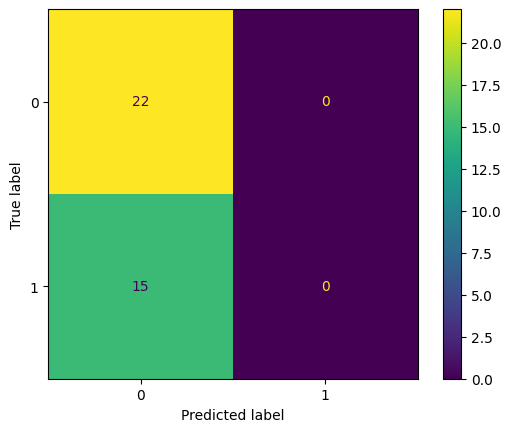

In [26]:
#docs_infra: no_execute
classes = [0, 1, 2, 3, 4]
classes = [0, 1]
cm=confusion_matrix(y_test_def2, y_pred2,labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [27]:
from sklearn.metrics import classification_report
target_names = ['class 0', 'class 1']
print(classification_report(y_test_def2, y_pred2, target_names=target_names, digits=4))

              precision    recall  f1-score   support

     class 0     0.5946    1.0000    0.7458        22
     class 1     0.0000    0.0000    0.0000        15

    accuracy                         0.5946        37
   macro avg     0.2973    0.5000    0.3729        37
weighted avg     0.3535    0.5946    0.4434        37



/home/rgadea/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/rgadea/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/rgadea/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
# model.save('modelos/modelote1203_200')  # creates a HDF5 file 'my_model.h5'

In [29]:
model.save('modelos/modelo_perfecto_{}_{}'.format(experimento,datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))) 

INFO:tensorflow:Assets written to: modelos/modelo_perfecto_LOMOS_Agilent_entradas_4_GRU_32_squeezenetv1_1_clases_2_loss_categorical_crossentropy_lr_0.001_algoritmo_rmsprop_20240819-204517/assets


INFO:tensorflow:Assets written to: modelos/modelo_perfecto_LOMOS_Agilent_entradas_4_GRU_32_squeezenetv1_1_clases_2_loss_categorical_crossentropy_lr_0.001_algoritmo_rmsprop_20240819-204517/assets


In [30]:
from scipy import stats
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_def)
#y_pred2 = scaler_out.inverse_transform(y_pred) #valor denormalizado

#y_pred1=y_pred[:,-1]
y_pred2=np.argmax(y_pred,axis=1)
n = len(y_pred2)
reshaped = y_pred2[:n//4*4].reshape(-1, 4)
mean_values = reshaped.mean(axis=1)

mean_values = np.round(mean_values)
mean_values = np.clip(mean_values, 0, 4)
mean_values = mean_values.astype(int)
print(mean_values)

mode_values = stats.mode(reshaped, axis=1)[0]
print(mode_values)

# Convierte los arrays a DataFrames
mean_df = pd.DataFrame(mean_values, columns=['mean'])
mode_df = pd.DataFrame(mode_values, columns=['mode'])

# Guarda los DataFrames en archivos Excel
mean_df.to_excel("clasificacion_P1P2_mean_best7.xlsx", index=False)
mode_df.to_excel("clasificacion_P1_mode_best7.xlsx", index=False)

NameError: name 'X_test_def' is not defined

In [ ]:
print(y_pred2)

In [ ]:
filename5 = "lomosP1_20240430_clasificado_experto.hdf"
with pd.HDFStore(filename5,complib="zlib",complevel=4) as hdf_db:
    pre_p_e2  = hdf_db.get('data/pollos_estado')
    pre_p_e2 = pre_p_e2.loc[pre_p_e2['Pollo'] != 0]
    pre_p_e2 =pre_p_e2.drop_duplicates(subset = ['Pollo', 'Medida'],  keep = 'last').reset_index(drop = True)
    t    = hdf_db.get('data/tabla')
    X_test2=np.zeros((pre_p_e2.shape[0],220,8))
    y_test2=np.zeros((pre_p_e2.shape[0],1))
    x=0
    for index, row in pre_p_e2.iterrows():   # El primer registro no se toma en cuenta porque es basura
        Primero = int(row['Primero'])
        Ultimo  = int(row['Ultimo'])
        estado  = int(row['Estado'])
        #print(Primero)
        #print(Ultimo)
        #print(estado)
        if estado == 0 or estado== 1:
           target = 1
        else:
           target = 0
        #target=estado
        pepito=np.array(t.iloc[Primero:Ultimo+1])
        # #print(pepito.shape)
        X_test2[x]=pepito[:,3:11]
        #print(X_train[x][0:4,:])       
        y_test2[x]=target
        y_test2_to_categorical = to_categorical(y_test2)
        x=x+1


# print(X_train.shape)
# print(y_train_to_categorical.shape)
# #print(X_train[0:4,:,:])
# #print(X_train[1][0:4][:])
# print(y_train[1:20])
# print(y_train_to_categorical[1:20])
# # #Aqui filtrariamos si hay filas que no nos interesan. En este caso dejo pasar todos los casos
# print(p_e)
# # X_train_filtrado = X_train[2:][:,:]
# # y_train_filtrado = y_train[2:]
X_test2_filtrado = X_test2
#y_train_filtrado = y_train
y_test2_filtrado = y_test2_to_categorical

print(X_test2_filtrado.shape)
print(y_test2_filtrado.shape)
# print(X_train_filtrado[0][:,:])
# # # Vamos a normalizar o escalar los datos
# concatenamos train y test
#X_total=np.concatenate((X_train_filtrado,X_test_filtrado),axis=0)
#scaler = MinMaxScaler(feature_range=(0, 1))
#data_2d_test = X_total.reshape(-1, X_total.shape[-1])
data_2d_test = X_test2_filtrado.reshape(-1, X_test2_filtrado.shape[-1])
normalized_data_2d_test = scaler.transform(data_2d_test)


X_test2_def=normalized_data_2d_test.reshape(X_test2_filtrado.shape) 
# la alternativa es normalizar con el total
# X_test_def=normalized_data_2d_test.reshape(X_test_filtrado.shape) 

y_test2_def=y_test2_filtrado # los valores ya estaban normalizados

print(y_test2_def.shape)

print(y_test2_filtrado)

In [ ]:
from scipy import stats
from sklearn.metrics import classification_report

# Crear un nuevo modelo con la misma arquitectura
best_val_model = create_model()  # Reemplaza esto con la función que usaste para crear el modelo original

# Cargar los mejores pesos
best_val_model.load_weights('best_weights.h5')

y_pred = best_val_model.predict(X_test2_def)
#y_pred2 = scaler_out.inverse_transform(y_pred) #valor denormalizado

#y_pred1=y_pred[:,-1]
y_pred2=np.argmax(y_pred,axis=1)
n = len(y_pred2)
print(n)
reshaped = y_pred2[:n//4*4].reshape(-1, 4)
mean_values = reshaped.mean(axis=1)

mean_values = np.round(mean_values)
mean_values = np.clip(mean_values, 0, 4)
mean_values = mean_values.astype(int)
print(mean_values.shape)

mode_values = stats.mode(reshaped, axis=1)[0]
print(mode_values.shape)

n = len(y_test2_def)
y_test2_def2=np.argmax(y_test2_def,axis=1)
print(y_test_def2.shape)
print(n)
reshaped2 = y_test2_def2[:n//4*4].reshape(-1, 4)
target_mean_values = reshaped2.mean(axis=1)

target_mean_values = np.round(target_mean_values)
target_mean_values = np.clip(target_mean_values, 0, 4)
target_mean_values = target_mean_values.astype(int)
print(target_mean_values.shape)

target_mode_values = stats.mode(reshaped2, axis=1)[0]
print(target_mode_values.shape)
print(reshaped)
print(mode_values)
print(target_mean_values)

In [ ]:
#docs_infra: no_execute
classes = [0, 1, 2, 3, 4]
classes = [0, 1]
cm=confusion_matrix(y_test2_def2, y_pred2,labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
print(cm.diagonal()/cm.sum(axis=1))

In [ ]:
target_names = ['class 0', 'class 1']
print(classification_report(target_mean_values, mean_values, target_names=target_names, digits=4))